# Импорт необходимых библиотек

In [ ]:
!pip install -r "requirements.txt"

# Загружаем данные

Загружаем граф из файла, записывая его вершины и ребра, а также создавая словарь для смежных вершин.

In [2]:
def load_graph(file, directed=False):
    edges = []
    nodes = set()
    adjacency = {}

    with open(file, 'r') as file:
        for line in file:
            if line.startswith('#') or not line.strip():
                continue
            u, v = map(int, line.strip().split())

            edges.append((u, v))
            nodes.update([u, v])

            if u not in adjacency:
                adjacency[u] = set()
            adjacency[u].add(v)

            if not directed:
                if v not in adjacency:
                    adjacency[v] = set()
                adjacency[v].add(u)

    return edges, nodes, adjacency
    

# Вспомогательные функции

In [3]:
def dfs(adjacency, node, visited, component=None, post_order=None):
    stack = [(node, False)]
    while stack:
        curr_node, children_visited = stack.pop()
        if curr_node not in visited:
            if children_visited:
                if post_order is not None:
                    post_order.append(curr_node)
            else:
                visited.add(curr_node)
                if component is not None:
                    component.append(curr_node)
                stack.append((curr_node, True))
                for neighbor in adjacency.get(curr_node, []):
                    if neighbor not in visited:
                        stack.append((neighbor, False))
                        

In [4]:
def reverse_graph(edges):
    reversed_graph = {}
    for u, v in edges:
        if v not in reversed_graph:
            reversed_graph[v] = set()
        reversed_graph[v].add(u)
    return reversed_graph
    

In [5]:
def count_links(adjacency: dict, node: int):
    neighbors = adjacency.get(node, set())
    links = 0
    neighbor_list = list(neighbors)
    n = len(neighbor_list)
    for i in range(n):
        u = neighbor_list[i]
        for j in range(i + 1, n):
            v = neighbor_list[j]
            if u in adjacency and v in adjacency[u]:
                links += 1
    return links
    

In [6]:
def count_triples(adjacency: dict):
    triples = 0.0
    for neighbors in adjacency.values():
        k = len(neighbors)
        triples += k * (k - 1) / 2
    return triples
    

Считаем общее число треугольников в графе (total_triangles) и средний кластерный коэффициент (```average_clustering```):

In [7]:
def compute_local_metrics(adjacency: dict):
    clustering_coeffs = []
    triangles_counted = 0

    for node, neighbors in adjacency.items():
        k = len(neighbors)    
        if k < 2:
            clustering_coeffs.append(0.0)
            continue

        links = count_links(adjacency, node)
        Ci = (2 * links) / (k * (k - 1))
        clustering_coeffs.append(Ci)

        triangles_counted += links

    total_triangles = triangles_counted // 3
    average_clustering = (
        sum(clustering_coeffs) / len(clustering_coeffs)
        if clustering_coeffs else 0.0
    )
    return total_triangles, average_clustering
    

In [8]:
def get_largest_weak_component_size(current_nodes, current_adj):
    visited = set()
    max_size = 0
    for node in current_nodes:
        if node not in visited:
            component = []
            dfs(current_adj, node, visited, component)
            max_size = max(max_size, len(component))
    return max_size / len(current_nodes) if current_nodes else 0
    

In [9]:
def remove_nodes(nodes_to_remove, adj):
    new_nodes = set(adj.keys()) - set(nodes_to_remove)
    new_adj = {}
    for u in new_nodes:
        neighbors = adj[u]
        new_adj[u] = set(v for v in neighbors if v in new_nodes)
    return list(new_nodes), new_adj
    

In [10]:
def bfs(adjacency, start):
    dist = {start: 0}
    queue = [start]
    while queue:
        node = queue.pop(0)
        for neighbor in adjacency.get(node, []):
            if neighbor not in dist:
                dist[neighbor] = dist[node] + 1
                queue.append(neighbor)
    return dist


In [11]:
def get_percentile(data, percent):
    if not data:
        return None
    data = sorted(data)
    n = len(data)
    k = (percent // 100) * (n - 1) + 1
    i = int(k)
    g = k - i
    if i + 1 < n:
        return data[i] + g * (data[i + 1] - data[i])
    else:
        return data[i]

# Анализ структуры сети

## Часть A

### Пункт 1

In [12]:
def graph_analysis_1(file, directed=False):
    edges, nodes, adjacency = load_graph(file, directed)
    
    num_nodes = len(nodes)
    num_edges = len(edges)
    
    max_edges = num_nodes * (num_nodes - 1)
    if not directed:
        max_edges //= 2
        
    density = num_edges / max_edges if max_edges else 0

    visited = set()
    weak_components = []
    for node in nodes:
        if node not in visited:
            component = []
            dfs(adjacency, node, visited, component)
            weak_components.append(component)

    num_weak_components = len(weak_components)
    share_max_weak_component = max(len(c) for c in weak_components) / num_nodes if num_nodes else 0

    print(f"Число вершин: {num_nodes}")
    print(f"Число ребер: {num_edges}")
    print(f"Плотность: {density:.5f}")
    print("--" * 20)
    print(f"Число компонент слабой связности: {num_weak_components}")
    if num_nodes <= 15:
            print(weak_components)
    print(f"Доля вершин в максимальной по мощности компоненте слабой связности: {share_max_weak_component:.5f}")
    
    if directed:
        reversed_graph = reverse_graph(edges)
        visited = set()
        post_order = []
        for node in nodes:
            if node not in visited:
                dfs(reversed_graph, node, visited, post_order)
                
        visited = set()
        strong_components = []
        for node in reversed(post_order):
            if node not in visited:
                component = []
                dfs(adjacency, node, visited, component)
                strong_components.append(component)
        
        num_strong_components = len(strong_components)
        share_max_strong_component = max(len(c) for c in strong_components) / num_nodes if num_nodes else 0
        
        print("--" * 20)  
        print(f"Число компонент сильной связности: {num_strong_components}")
        if num_nodes <= 15:
            print(strong_components)
        print(f"Доля вершин в максимальной компоненте сильной связности: {share_max_strong_component:.5f}")
        

In [13]:
graph_analysis_1("test_graph.txt", directed=True)

Число вершин: 14
Число ребер: 16
Плотность: 0.08791
----------------------------------------
Число компонент слабой связности: 3
[[1, 2, 3, 5, 4], [6, 7, 10, 12, 13, 8, 9, 11], [14]]
Доля вершин в максимальной по мощности компоненте слабой связности: 0.57143
----------------------------------------
Число компонент сильной связности: 7
[[14], [13], [12], [11], [10], [7, 8, 9, 6], [4, 2, 3, 5, 1]]
Доля вершин в максимальной компоненте сильной связности: 0.35714


### Пункт 2

In [14]:
import random

def graph_analysis_2(file, sample_size=500):
    _, nodes, adjacency = load_graph(file)

    visited = set()
    components = []
    for node in nodes:
        if node not in visited:
            component = []
            dfs(adjacency, node, visited, component=component)
            components.append(component)

    if not components:
        print("Граф пуст или без ребер")
        return

    largest_component = max(components, key=len)
    largest_component_set = set(largest_component)

    tmp_adjacency = {}
    for u in largest_component:
        neighbors = adjacency.get(u, set())
        filtered_neighbors = set()
        for v in neighbors:
            if v in largest_component_set:
                filtered_neighbors.add(v)
        tmp_adjacency[u] = filtered_neighbors

    # --- A --- 
    r = random.choice(largest_component)
    dist_r = bfs(tmp_adjacency, r)
    a = max(dist_r, key=dist_r.get)
    dist_a = bfs(tmp_adjacency, a)
    b = max(dist_a, key=dist_a.get)
    diameter = dist_a[b]
    print(f"[Двойной проход BFS] Диаметр (ecc(a) = d(a, b)): {diameter}")

    # --- B --- 
    sample_nodes = random.sample(largest_component, min(sample_size, len(largest_component)))
    dist = []
    for u in sample_nodes:
        dist_u = bfs(tmp_adjacency, u)
        for v in sample_nodes:
            if v != u and v in dist_u:
                dist.append(dist_u[v])
    if dist:
        print(f"[Случайно выбранные вершины] Оценка диаметра: {max(dist)}")
        print(f"[Случайно выбранные вершины] 90-й процентиль расстояний: {round(get_percentile(dist, 90), 5)}")

    # --- C --- 
    adj_pairs = []
    for u in largest_component:
        for v in tmp_adjacency.get(u, []):
            if u < v:
                adj_pairs.append((u, v))
    
    if not adj_pairs:
        print("Нет смежных узлов в наибольшей компоненте.")
        return
    
    start_node_1, start_node_2 = random.choice(adj_pairs)
    
    snowball = {start_node_1, start_node_2}
    frontier = {start_node_1, start_node_2}
    
    while len(snowball) < sample_size:
        next_frontier = set()
        for node in frontier:
            for neighbor in tmp_adjacency.get(node, []):
                if neighbor not in snowball:
                    snowball.add(neighbor)
                    next_frontier.add(neighbor)
        if not next_frontier:
            break
        frontier = next_frontier
    
    snowball_nodes = list(snowball)
    
    snowball_tmp_adjacency = {}
    
    for u in snowball:
        filtered_neighbors = []
        for v in tmp_adjacency.get(u, []):
            if v in snowball:
                filtered_neighbors.append(v)
        snowball_tmp_adjacency[u] = filtered_neighbors
    
    dist = []
    for u in snowball_nodes:
        dist_u = bfs(snowball_tmp_adjacency, u)
        for v in snowball_nodes:
            if v != u and v in dist_u:
                dist.append(dist_u[v])
    
    if dist:
        print(f"[Снежный ком] Оценка диаметра: {max(dist)}")
        print(f"[Снежный ком] 90-й процентиль расстояний: {round(get_percentile(dist, 90), 5)}")


In [15]:
graph_analysis_2("test_graph.txt")

[Двойной проход BFS] Диаметр (ecc(a) = d(a, b)): 4
[Случайно выбранные вершины] Оценка диаметра: 4
[Случайно выбранные вершины] 90-й процентиль расстояний: 1
[Снежный ком] Оценка диаметра: 4
[Снежный ком] 90-й процентиль расстояний: 1


### Пункт 3

In [16]:
def graph_analysis_3(file):
    _, _, adjacency = load_graph(file)
    total_triangles, avg_clustering = compute_local_metrics(adjacency)
    triples = count_triples(adjacency)
    global_clustering = 0.0
    if triples > 0:
        global_clustering = 3 * total_triangles / triples


    print(f"Число треугольников: {total_triangles}")
    print(f"Средний кластерный коэффициент: {avg_clustering:.5f}")
    print(f"Глобальный кластерный коэффициент: {global_clustering:.5f}")
    

In [17]:
graph_analysis_3("test_graph.txt")

Число треугольников: 1
Средний кластерный коэффициент: 0.11905
Глобальный кластерный коэффициент: 0.13636


### Пункт 4

Перейдем к задаче вычислению среднего кластерного коэффициента сети для наибольшей компоненты слабой связности.

Для этого: 
- найдем компоненты слабой связаности и выберем наибольшую из них
- перезапишем для этой компоненты словарь со смежными вершинами (в коде дополнительно создадим множество ``` largest_component_set ```, чтобы ускорить обращение к вершинам: ```v in largest_component_set```)
- передадим его (как в **3 пункте**) в функцию для вычислению среднего кластерного коэффициента.

In [18]:
def graph_analysis_4(file):
    _, nodes, adjacency = load_graph(file)
    
    visited = set()
    weak_components = []
    for node in nodes:
        if node not in visited:
            component = []
            dfs(adjacency, node, visited, component)
            weak_components.append(component)

    if not weak_components:
        print("Граф пуст или без ребер")
        return

    largest_component = max(weak_components, key=len)
    largest_component_set = set(largest_component)
    
    tmp_adjacency = {}
    
    for u in largest_component:
        neighbors = adjacency.get(u, set())
        tmp_set = set()
        for v in neighbors:
            if v in largest_component_set:
                tmp_set.add(v)
        tmp_adjacency[u] = tmp_set


    _, avg_clustering = compute_local_metrics(tmp_adjacency)

    print(f"Средний кластерный коэффициент наибольшей компоненты слабой связности: {avg_clustering:.5f}")
    

In [19]:
graph_analysis_4("test_graph.txt")

Средний кластерный коэффициент наибольшей компоненты слабой связности: 0.00000


### Пункт 5

In [20]:
import matplotlib.pyplot as plt

def graph_analysis_5(file):
    _, nodes, adjacency = load_graph(file)

    degrees = [len(adjacency.get(node, [])) for node in nodes]
    if not degrees:
        print("Степеней вершин нет")
        return

    min_deg = min(degrees)
    max_deg = max(degrees)
    avg_deg = sum(degrees) / len(degrees)

    print(f"Минимальная степень: {min_deg}")
    print(f"Максимальная степень: {max_deg}")
    print(f"Средняя степень: {avg_deg:.5f}")

    degree_counts = {}
    for deg in degrees:
        if deg in degree_counts:
            degree_counts[deg] += 1
        else:
            degree_counts[deg] = 1

    total_nodes = len(degrees)
    
    degree_values = sorted(degree_counts.keys())
    probabilities = []
    for k in degree_values:
        probabilities.append(degree_counts[k] / total_nodes)


    plt.figure(figsize=(12, 5))

    plt.plot(degree_values, probabilities, marker='o')
    plt.title('Функция вероятности в обычных шкалах')
    plt.xlabel('Степень вершины - k')
    plt.ylabel('P(k)')
    plt.grid(True, which='both')
    plt.show()
    
    plt.loglog(degree_values, probabilities, marker='o')
    plt.title('Функция вероятности в log-log шкалах')
    plt.xlabel('log(k)')
    plt.ylabel('log(P(k))')
    plt.grid(True, which='both')
    plt.show()


Минимальная степень: 1
Максимальная степень: 3
Средняя степень: 2.21429


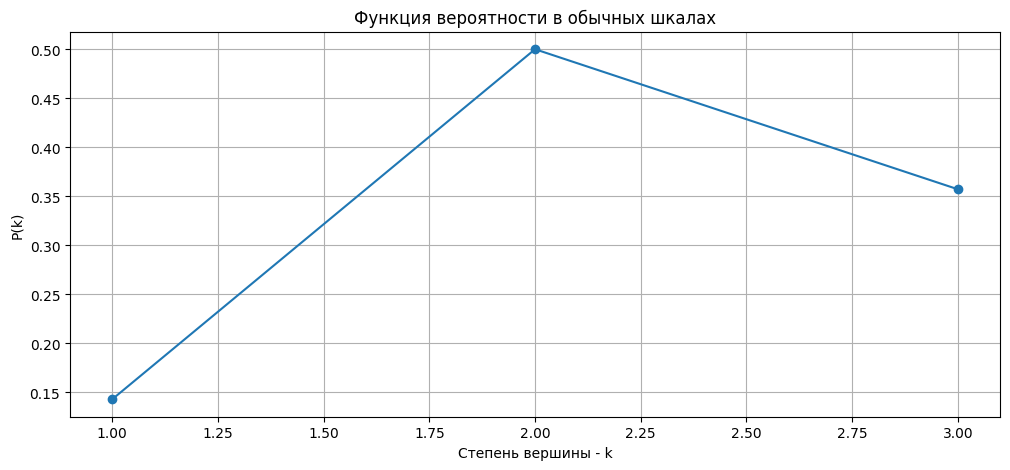

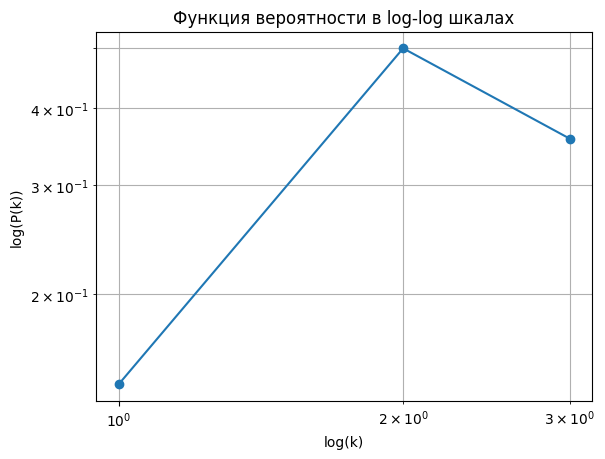

In [21]:
graph_analysis_5("test_graph.txt")

## Часть B

In [22]:
import random
import matplotlib.pyplot as plt

def graph_analysis(file, x_values=range(1, 101, 5)):
    _, nodes, adjacency = load_graph(file)
    nodes = list(nodes)
    random_results = []
    degree_based_results = []

    print("Анализ устойчивости графа к удалению узлов:\n")

    for x in x_values:
        num_remove = int(len(nodes) * x / 100)

        random_nodes = nodes.copy()
        random.shuffle(random_nodes)
        removed_random = random_nodes[:num_remove]
        new_nodes_rnd, new_adj_rnd = remove_nodes(removed_random, adjacency)
        largest_component_size_rnd = get_largest_weak_component_size(new_nodes_rnd, new_adj_rnd)
        random_results.append(largest_component_size_rnd)

        degree_sorted = sorted(nodes, key=lambda n: len(adjacency.get(n, [])), reverse=True)
        removed_top = degree_sorted[:num_remove]
        new_nodes_deg, new_adj_deg = remove_nodes(removed_top, adjacency)
        largest_component_size_deg = get_largest_weak_component_size(new_nodes_deg, new_adj_deg)
        degree_based_results.append(largest_component_size_deg)

        print(f"{x}% удалено:")
        print(f"  [Случайное удаление] Доля в наибольшей компоненте слабой связности: {largest_component_size_rnd:.5f}")
        print(f"  [Удаление по степени] Доля в наибольшей компоненте слабой связности: {largest_component_size_deg:.5f}")

    plt.figure(figsize=(10, 6))
    plt.plot(x_values, random_results, label='Случайное удаление', marker='o')
    plt.plot(x_values, degree_based_results, label='Удаление узлов наибольшей степени', marker='s')
    plt.xlabel('Удалено узлов (x%)')
    plt.ylabel('Доля вершин в наибольшей компоненте слабой связности')
    plt.legend()
    plt.grid(True, which='both')
    plt.title("Устойчивость графа при удалении узлов")
    plt.show()


Анализ устойчивости графа к удалению узлов:

1% удалено:
  [Случайное удаление] Доля в наибольшей компоненте слабой связности: 0.57143
  [Удаление по степени] Доля в наибольшей компоненте слабой связности: 0.57143
6% удалено:
  [Случайное удаление] Доля в наибольшей компоненте слабой связности: 0.57143
  [Удаление по степени] Доля в наибольшей компоненте слабой связности: 0.57143
11% удалено:
  [Случайное удаление] Доля в наибольшей компоненте слабой связности: 0.53846
  [Удаление по степени] Доля в наибольшей компоненте слабой связности: 0.61538
16% удалено:
  [Случайное удаление] Доля в наибольшей компоненте слабой связности: 0.66667
  [Удаление по степени] Доля в наибольшей компоненте слабой связности: 0.66667
21% удалено:
  [Случайное удаление] Доля в наибольшей компоненте слабой связности: 0.41667
  [Удаление по степени] Доля в наибольшей компоненте слабой связности: 0.66667
26% удалено:
  [Случайное удаление] Доля в наибольшей компоненте слабой связности: 0.54545
  [Удаление по с

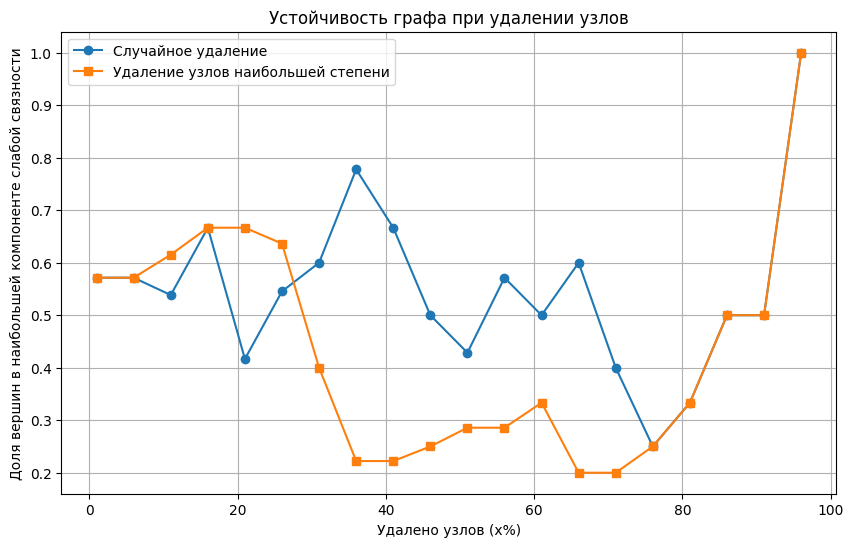

In [23]:
graph_analysis("test_graph.txt")